In [1]:
# import statements
import pandas as pd
import requests
import json

import matplotlib.pyplot as plt


## Data Handling + Split

In [ ]:
#call data and clean (remove null and duplicate values)
df_old = pd.read_csv('agriculture_dataset.csv')
df_old=df_old.drop_duplicates()

missing_codes = ["--", "", " ", "nan", "NaN", "None"] #account for different possible null combos


for col in df_old.columns:
    if df_old[col].dtype == object:  # only clean string/object columns
        df_old[col] = df_old[col].str.strip().replace(missing_codes, pd.NA)
    else:
        df_old[col] = df_old[col].replace(missing_codes, pd.NA) 

df_old = df_old.dropna()  # remove rows with any null values

print(df_old.columns)
df_old.head()

Index(['High_Resolution_RGB', 'Multispectral_Images', 'Thermal_Images',
       'Temporal_Images', 'Spatial_Resolution', 'GPS_Coordinates',
       'Field_Boundaries', 'Elevation_Data', 'Canopy_Coverage', 'NDVI', 'SAVI',
       'Chlorophyll_Content', 'Leaf_Area_Index', 'Crop_Stress_Indicator',
       'Temperature', 'Humidity', 'Rainfall', 'Wind_Speed', 'Soil_Moisture',
       'Soil_pH', 'Organic_Matter', 'Pest_Hotspots', 'Weed_Coverage',
       'Pest_Damage', 'Crop_Growth_Stage', 'Expected_Yield', 'Crop_Type',
       'Ground_Truth_Segmentation', 'Bounding_Boxes', 'Water_Flow',
       'Drainage_Features', 'Crop_Health_Label'],
      dtype='object')


,High_Resolution_RGB,Multispectral_Images,Thermal_Images,Temporal_Images,Spatial_Resolution,GPS_Coordinates,Field_Boundaries,Elevation_Data,Canopy_Coverage,NDVI,...,Weed_Coverage,Pest_Damage,Crop_Growth_Stage,Expected_Yield,Crop_Type,Ground_Truth_Segmentation,Bounding_Boxes,Water_Flow,Drainage_Features,Crop_Health_Label
0,0,0,0,0,0.667324,201538,3,28.207634,8.046926,0.676945,...,1.922274,84,2,2540.784327,Wheat,1,5,41.771884,0,1
1,1,1,0,0,1.459000,215854,3,82.335147,147.512332,0.414781,...,4.851381,56,3,3227.617025,Wheat,0,1,27.564635,0,1
2,0,0,0,0,0.500442,890802,3,83.865629,30.246527,0.723610,...,5.974859,38,1,4609.938146,Maize,1,8,29.510836,0,1
3,0,0,0,0,1.865161,605584,3,20.747905,6.857820,0.405611,...,2.100598,27,2,1409.716754,Maize,0,1,34.822855,0,0
4,0,1,1,1,1.392331,871732,3,22.588815,26.168558,0.465992,...,3.025669,84,4,3905.312588,Rice,0,2,15.493255,1,0


In [3]:
import numpy as np

#Randomly remove percent of elements of data to improve efficiency
percentRemove=0.5
num_rows_rem=int(len(df_old)*percentRemove)

rows_remove=np.random.choice(df_old.index, num_rows_rem, replace=False)
df = df_old.drop(rows_remove)

del df_old

df.head()

,High_Resolution_RGB,Multispectral_Images,Thermal_Images,Temporal_Images,Spatial_Resolution,GPS_Coordinates,Field_Boundaries,Elevation_Data,Canopy_Coverage,NDVI,...,Weed_Coverage,Pest_Damage,Crop_Growth_Stage,Expected_Yield,Crop_Type,Ground_Truth_Segmentation,Bounding_Boxes,Water_Flow,Drainage_Features,Crop_Health_Label
4,0,1,1,1,1.392331,871732,3,22.588815,26.168558,0.465992,...,3.025669,84,4,3905.312588,Rice,0,2,15.493255,1,0
8,0,0,1,0,0.862034,300672,3,23.027399,3.294899,0.500893,...,1.884896,21,3,2492.937443,Wheat,1,4,18.688151,0,1
13,0,0,0,0,1.775103,222077,3,55.709859,12.998474,0.282417,...,5.373410,92,1,2395.511961,Maize,1,1,17.766502,0,1
15,0,0,0,0,1.501895,800950,1,52.501510,41.323763,0.677382,...,3.702570,54,4,3824.756238,Maize,0,7,26.377158,1,0
19,0,1,0,0,0.985666,922846,3,31.937428,31.744834,0.578472,...,1.114945,85,2,2794.849559,Maize,0,8,30.217712,0,1


In [16]:
#one-hot encoding to turn categorical value into numerical
#create df_sub and df_sub_drop (clean dataset/create subsets)
df_sub = df.drop(columns='Crop_Health_Label', axis=1)
df_sub = pd.get_dummies(df_sub, columns=['Crop_Type'], dtype=int)

columnsToDrop = ['High_Resolution_RGB','Multispectral_Images', 'Thermal_Images',
       'Temporal_Images','Field_Boundaries', 'Pest_Hotspots','Crop_Growth_Stage',
       'Crop_Type_Maize','Crop_Type_Rice','Crop_Type_Wheat', 
       'Ground_Truth_Segmentation', 'Bounding_Boxes', 'Drainage_Features']
df_sub_drop = df_sub.drop(columns=columnsToDrop, axis=1)

df_sub_drop.head()
#df_sub.head()


,Spatial_Resolution,GPS_Coordinates,Elevation_Data,Canopy_Coverage,NDVI,SAVI,Chlorophyll_Content,Leaf_Area_Index,Crop_Stress_Indicator,Temperature,Humidity,Rainfall,Wind_Speed,Soil_Moisture,Soil_pH,Organic_Matter,Weed_Coverage,Pest_Damage,Expected_Yield,Water_Flow
4,1.392331,871732,22.588815,26.168558,0.465992,0.269888,2.111205,0.438672,79,22.502605,64.438963,9.492281,2.281165,8.295005,7.664008,3.520753,3.025669,84,3905.312588,15.493255
8,0.862034,300672,23.027399,3.294899,0.500893,0.581525,0.253741,1.843274,37,16.015674,53.258520,12.272348,1.144819,7.052581,5.735913,2.363925,1.884896,21,2492.937443,18.688151
13,1.775103,222077,55.709859,12.998474,0.282417,0.396177,1.505957,2.433341,49,16.273542,54.082743,0.065588,4.461736,9.634588,6.364534,0.199455,5.373410,92,2395.511961,17.766502
15,1.501895,800950,52.501510,41.323763,0.677382,0.330276,0.946745,2.045189,76,32.807295,58.025993,0.608460,3.225570,29.894616,6.299460,1.780280,3.702570,54,3824.756238,26.377158
19,0.985666,922846,31.937428,31.744834,0.578472,0.525808,1.258198,0.770480,78,21.900325,53.981207,10.252957,2.436274,17.546336,5.709623,0.011676,1.114945,85,2794.849559,30.217712


In [5]:
#binary columns to add back
binary_cols = df_sub[['Pest_Hotspots','Crop_Growth_Stage',
       'Crop_Type_Maize','Crop_Type_Rice','Crop_Type_Wheat', 
       'Ground_Truth_Segmentation', 'Bounding_Boxes', 'Drainage_Features']].to_numpy()


In [6]:
df_sub_drop.shape

(106010, 20)

In [7]:
from sklearn.model_selection import train_test_split
#split continuous and binary data at same time, consistent rand state
y_vec = df['Crop_Health_Label'].to_numpy()

X_train_cont, X_test_cont, y_train, y_test = train_test_split(
    df_sub_drop.to_numpy(), y_vec, test_size=0.2, random_state=3000
)
binary_train, binary_test, _, _ = train_test_split(
    binary_cols, y_vec, test_size=0.2, random_state=3000
)

In [8]:
import numpy as np
from sklearn.preprocessing import StandardScaler

#scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_cont)
X_test_scaled = scaler.transform(X_test_cont)

#add binary columns back
X_train = np.concatenate([X_train_scaled, binary_train], axis=1)
X_test = np.concatenate([X_test_scaled, binary_test], axis=1)

pd.DataFrame(X_train_scaled).head()
#pd.DataFrame(X_test_scaled).head()



,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,1.667821,0.499916,0.619572,-0.718319,-0.908104,1.309292,-0.803083,2.114846,-0.505383,2.604250,-1.621395,-0.983683,-0.760812,1.113985,0.019112,-0.980821,0.487710,0.293286,-0.218844,1.623832
1,-0.102448,0.597155,-1.151741,-0.816957,0.313406,1.191002,-0.100025,0.431326,-0.539992,1.569409,0.293855,-0.548531,-1.029521,0.664346,-1.224456,0.209664,-1.536619,0.639639,1.289410,-1.320781
2,-1.309359,0.010113,1.006416,-0.211218,0.904539,1.358747,0.799874,1.378208,0.048352,-0.730409,1.076183,-0.360664,-1.184486,-1.199268,1.759162,-0.439785,-1.137077,0.362556,-0.297379,-1.093194
3,-0.297497,0.418775,-0.962353,1.249131,0.222429,0.680127,0.852866,-0.564371,-1.128335,-1.091824,-0.877601,-0.346863,-0.694150,0.461365,0.987630,-0.997560,-0.207967,1.089899,0.260606,0.053811
4,-0.092694,0.470499,-0.284340,1.751226,-1.570160,0.330611,-0.851140,-0.483071,1.017388,0.268721,-0.831859,0.177029,0.962348,1.552538,0.057830,1.439417,0.796807,0.743545,-0.105327,1.493969


## KNN Regressor

In [10]:
#Cosine KNN-model1
def knn_reg_cos(X_train, y_train, X_test, k):
    """
    Args:
    X_train: numpy array of shape (n_samples, n_features) - training data features
    y_train: numpy array of shape (n_samples,) - training data target values
    X_test: numpy array of shape (m_samples, n_features) - test data features
    k: int - number of nearest neighbors to consider

    Returns:
    y_pred: numpy array of shape (m_samples,) - predicted target values for the test data
    nearest_neighbors: list of lists - indices of the k nearest neighbors for each test point
    """
    
    #get norms
    train_norms = np.linalg.norm(X_train, axis=1, keepdims=True)
    test_norms = np.linalg.norm(X_test, axis=1, keepdims=True)
    
    X_train_norm = X_train / train_norms
    X_test_norm = X_test / test_norms
    
    # All cosine sims in one matrix multiply
    similarity_matrix = X_test_norm @ X_train_norm.T
    
    neighbor_indices = np.argsort(similarity_matrix, axis=1)[:, -k:]
    y_pred = y_train[neighbor_indices].mean(axis=1)
    
    return y_pred, neighbor_indices.tolist()

In [ ]:
def knn_cos_with_loop(X_train, y_train, X_test, k):

    y_pred = []
    nearest_neighbors = []

    train_norms = np.linalg.norm(X_train, axis=1, keepdims=True)
    
    X_train_norm = X_train / train_norms
    #i = 0
    for testp in X_test:
        #i += 1
        #print(f'The current iteration is: {i}', end='\r')

        norm_test = testp/np.linalg.norm(testp)
        similarities = norm_test @ X_train_norm.T
        #print(similarities.shape)
            
        neighbor_indices = np.argsort(similarities)[-k:]
        del similarities
        #print(neighbor_indices)
        neighbor_values = y_train[neighbor_indices]
        #print(neighbor_values)

        y_pred.append(np.mean(neighbor_values))
        nearest_neighbors.append(neighbor_indices)
    
    return np.array(y_pred), nearest_neighbors

In [12]:
#l2 norm-model 2
def knn_reg_l2(X_train, y_train, X_test, k):
    """
    Args:
    X_train: numpy array of shape (n_samples, n_features) - training data features
    y_train: numpy array of shape (n_samples,) - training data target values
    X_test: numpy array of shape (m_samples, n_features) - test data features
    k: int - number of nearest neighbors to consider
    
    Returns:
    y_pred: numpy array of shape (m_samples,) - predicted target values for the test data
    nearest_neighbors: list of lists - indices of the k nearest neighbors for each test point
    """
    train_sq = np.sum(X_train**2, axis=1)
    test_sq = np.sum(X_test**2, axis=1)

    asqr=test_sq[:, None]
    print(f"len of asqr: {len(asqr)}")
    bsqr=train_sq[None, :]
    print(bsqr)
    print(f"len of bsqr: {len(bsqr)}")


    ab=X_test @ X_train.T
    print(ab.shape())


    dist_matrix = asqr + bsqr - 2 * (ab)
    dist_matrix = np.sqrt(np.maximum(dist_matrix, 0))  # avoid negative sqrt
    
    neighbor_indices = np.argsort(dist_matrix, axis=1)[:, :k]
    y_pred = y_train[neighbor_indices].mean(axis=1)
    
    return y_pred, neighbor_indices.tolist()

In [10]:
X_train.shape

(84808, 28)

## plot data with ks and model

In [14]:
# k=2
# y_pred, _ = knn_cos_with_loop(X_train, y_train, X_test, k)
# mse = np.mean((y_test - y_pred) ** 2)

# plt.figure(figsize=(10, 6))
# plt.plot(k, mse, marker='o')
# plt.title('MSE of k-NN Regressor with Cosine Similarity')
# plt.xlabel('k (number of neighbors)')
# plt.ylabel('Mean Squared Error')
# plt.xticks(k)
# plt.grid()

We are beginning the modeling of k=1
We are beginning the modeling of k=2
We are beginning the modeling of k=3
We are beginning the modeling of k=4
We are beginning the modeling of k=5


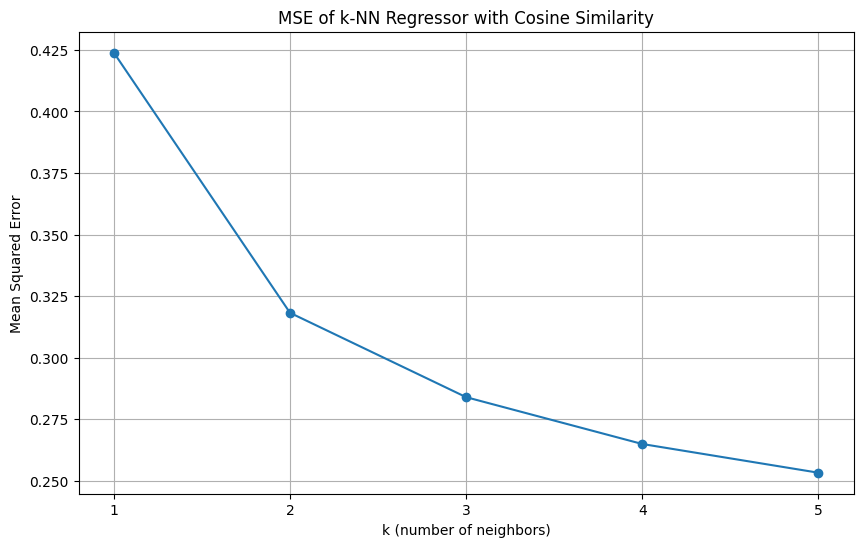

In [14]:
# loop through different values of k, keeping track of MSE for the test set predictions
# first with cosine similarity
k_values = [1, 2, 3, 4, 5]
mse_values = []
for k in k_values:
    print(f'We are beginning the modeling of k={k}')
    y_pred, _ = knn_cos_with_loop(X_train, y_train, X_test, k)
    mse = np.mean((y_test - y_pred) ** 2)
    mse_values.append(mse)

# plot the MSE values for different k
plt.figure(figsize=(10, 6))
plt.plot(k_values, mse_values, marker='o')
plt.title('MSE of k-NN Regressor with Cosine Similarity')
plt.xlabel('k (number of neighbors)')
plt.ylabel('Mean Squared Error')
plt.xticks(k_values)
plt.grid()

In [ ]:
#l2 norm model
mse_values_l2 = []
for k in k_values:
    y_pred_l2, _ = knn_reg_l2(X_train, y_train, X_test, k)
    mse_l2 = np.mean((y_test - y_pred_l2) ** 2)
    mse_values_l2.append(mse_l2)

# plot the MSE values for different k for L2 distance
plt.figure(figsize=(10, 6))
plt.plot(k_values, mse_values_l2, marker='o', color='orange')
plt.title('MSE of k-NN Regressor with L2 Distance')
plt.xlabel('k (number of neighbors)')
plt.ylabel('Mean Squared Error')
plt.xticks(k_values)
plt.grid()